In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# Converting Voltage to Light Output

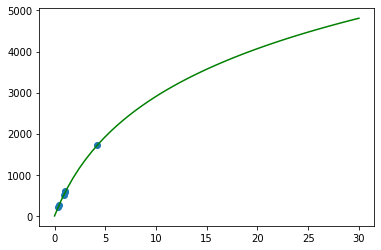

In [3]:
# plt.plot(np.linspace(0,5,50), exponential(np.linspace(0,5,50), *cali_params))

cal_x = np.array([0.4758, 1.0406, 0.9033, 0.3755, 1.0670, 4.1984])
cal_y = np.array([256.5, 581.87, 509.15, 206.8, 608.77, 1714.9]) 

def logarithmic(x, a, b, c):
    return a*np.log(b*x+1)+c*x

l_params, cov = curve_fit(
    logarithmic,
    cal_x,
    cal_y,
    bounds=((0, 0, 0),(20e3, 20, 3e3))
)

f_cal = np.poly1d(np.polyfit(cal_x, cal_y, 2))

xspace = np.linspace(0,30,50)
plt.plot(xspace, logarithmic(xspace,*l_params) ,'g')
plt.scatter(cal_x, cal_y)

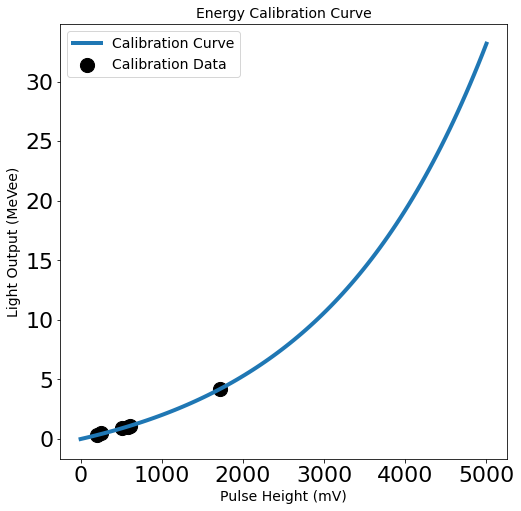

In [35]:
from pynverse import inversefunc
from scipy.interpolate import interp1d


fig, ax = plt.subplots(figsize=(8,8))

yspace = np.linspace(0,5000,100)
inv_vals = inversefunc(lambda x: logarithmic(x, *l_params), y_values=yspace)
f_l = np.poly1d(np.polyfit(yspace, inv_vals, 9))

ax.plot(yspace, inv_vals, lw=4, label="Calibration Curve")
# ax.plot(logarithmic(xspace,*l_params), xspace ,'r--', lw=4)
# ax.plot(yspace, f_l(yspace),'--', lw=4, alpha=0.95, label="Fitted")
ax.scatter(cal_y, cal_x, c="k", label="Calibration Data", s=200)

fontsize=14
ax.legend(fontsize=fontsize)
ax.set_title("Energy Calibration Curve", fontsize=fontsize)
ax.set_ylabel("Light Output (MeVee)", fontsize=fontsize)
ax.set_xlabel("Pulse Height (mV)", fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

# plt.scatter(cal_y, cal_x)
# inv_vals = inversefunc(lambda x: f_cal(x), y_values=yspace)
# f_l = interp1d(yspace, inv_vals, kind="cubic", fill_value="extrapolate")



In [4]:
def v_to_l(voltage):
    return f_l(voltage)

# LOADING DATA

In [5]:
ROOT = Path("../sample_datasets/")

EXP_DATES = ["20220801", "20221014", "20221020", "20221028", "20221028"]
EXP_ROOTS = [ROOT / f"{EXP_DATE}_experiments" for EXP_DATE in EXP_DATES]

def load_psd_data(psd_path: Path, amplitudes_path: Path) -> pd.DataFrame:
    psd = pd.read_csv(psd_path, header=None)
    amplitudes = pd.read_csv(amplitudes_path, header=None)
    psd_report = pd.concat([psd, amplitudes], axis=1)
    psd_report.columns = ["tail / total", "amplitude"]
    psd_report = psd_report.dropna()
    
    # Adjusting data
    psd_report = psd_report[psd_report["tail / total"].between(0, 0.6)]
    psd_report["energy"] = (psd_report["amplitude"] * 1e3).apply(v_to_l)
    
    return psd_report

def load_experiment(EXP_ROOT):
    data = {
        "background": None,
        "echem": None,
        "echem_plasma": None,
        "plasma": None
    }
    
    for key in data.keys():
        if not (EXP_ROOT / key).exists():
            data[key] = None
            continue
        
        AMPLITUDES_PATH = EXP_ROOT / key / "amplitudes.csv"
        PSD_PATH = EXP_ROOT / key / "PSD.csv"
           
        data[key] = load_psd_data(PSD_PATH, AMPLITUDES_PATH)
        
    return data

In [6]:
# experiments = {EXP_DATE: load_experiment(EXP_ROOT) for EXP_DATE, EXP_ROOT in zip(EXP_DATES, EXP_ROOTS)}
import pickle

with open('experiments_data.pickle', 'rb') as f:
     experiments = pickle.load(f) 

In [7]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

ROOT = Path("../sample_datasets/20221031_AmBe/")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

ambe_report = load_psd_data(PSD_PATH, AMPLITUDES_PATH)
ambe_report = ambe_report.dropna(axis=0)
ambe_report = ambe_report[ambe_report["tail / total"].between(0,0.5)]

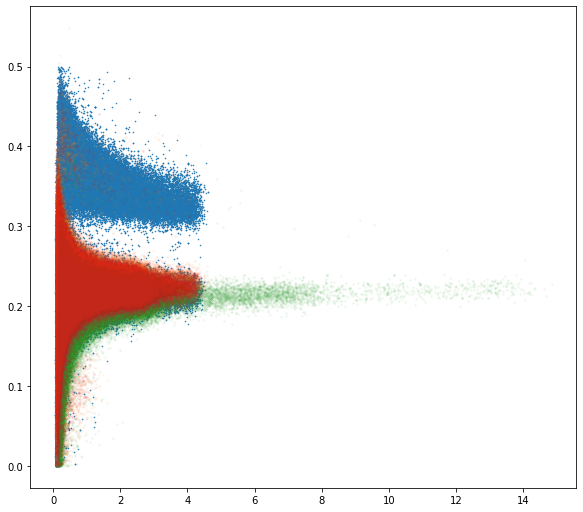

In [8]:
fig, ax = plot_scatter(ambe_report["energy"], ambe_report["tail / total"])

experiment_tag = "background"
exp2_tag = "echem"
ax.scatter(experiments["20221028"][experiment_tag]["energy"],experiments["20221028"][experiment_tag]["tail / total"], s=3, alpha=0.05)
ax.scatter(experiments["20220801"][experiment_tag]["energy"],experiments["20220801"][experiment_tag]["tail / total"], s=3, alpha=0.05)
ax.scatter(experiments["20221020"][exp2_tag]["energy"],experiments["20221020"][exp2_tag]["tail / total"], s=3, alpha=0.05)

fig.set_figheight(7)
fig.set_figwidth(8)
# ax.set_ylim(0,0.5)

In [9]:
psd_report = pd.DataFrame([], columns=["tail / total", "amplitude", "energy"])

for experiment_date in experiments.keys():
    experiment_data = experiments[experiment_date]
    
    for exp_type in experiment_data:
        psd_report = pd.concat([psd_report, experiment_data[exp_type]])

In [10]:
psd_report = pd.concat([psd_report, ambe_report])

In [11]:
psd_report.head()

,tail / total,amplitude,energy
0,0.171423,0.19799,0.325818
1,0.183065,0.33517,0.570584
2,0.198736,1.0415,2.123403
3,0.214533,0.27355,0.458625
4,0.202111,0.77294,1.469758


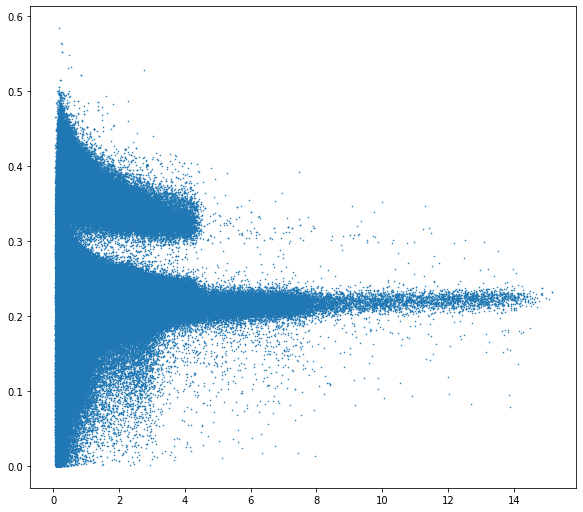

In [12]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)

In [13]:
def prep_df_for_slicing(dataframe, resolution):
    x, y = dataframe["energy"], dataframe["tail / total"]
    Z, xe, ye = np.histogram2d(x, y, resolution)
    return Z, xe, ye

def plot_histogram(Z, xe, ye):
    L4_e = xe[-2]  # what is this for?
    cmap = plt.colormaps["plasma"]
    plt.pcolormesh(xe, ye, Z.T, cmap=cmap)

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [14]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 8.5]))

cutoffs = [L1, L2, L3]

# Altogether

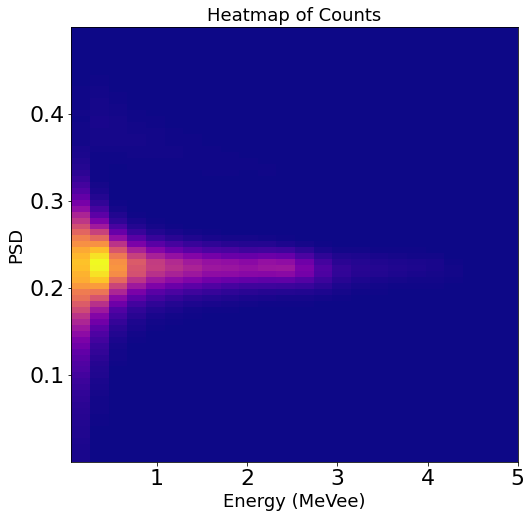

In [15]:
# generating psd/energy 2D histogram
resolution = 73
fontsize = 18
lim_psd = psd_report[psd_report["tail / total"].between(0, 0.5)]
x, y = lim_psd["energy"], lim_psd["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["plasma"]
ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

ax.set_xlim(xe[0],5)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [16]:
# slice width
f"{xe[2] - xe[1]:.4f} MeVee"

'0.2068 MeVee'

Text(0.5, 0, 'Counts')

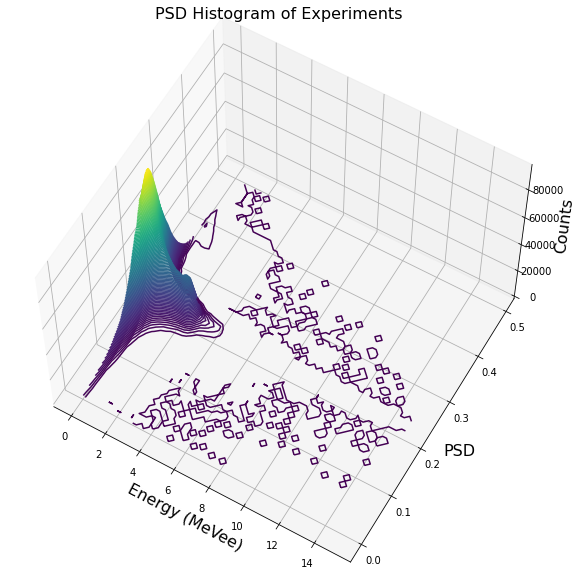

In [17]:
# histogram contour plot (vaporwave island)
contour_res = 150
angle_elev = 60
angle_rot = -60

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])

ax.view_init(angle_elev, angle_rot)
ax.contour3D(x, y, Z.T, contour_res)
ax.set_title("PSD Histogram of Experiments", fontsize=16)
ax.set_ylabel("PSD", fontsize=16)
ax.set_xlabel("Energy (MeVee)", fontsize=16)
ax.set_zlabel("Counts", fontsize=16)

In [18]:
# 3D plot view animation

import functools
from matplotlib.animation import FuncAnimation

def sum_frame_tuples(a, b):
  return tuple(i+j for i,j in zip(a, b))

def get_view_angle_ranges(hold_frames, transition_frames):
  hold_ranges = []
  transition_ranges = []
  start_i = 0
  for h, t in zip(hold_frames, transition_frames):
    hold_ranges.append((start_i, start_i + h))
    transition_ranges.append((start_i + h, start_i + h + t))
    start_i = start_i + h + t
  return hold_ranges, transition_ranges

def find_matching_range(i, ranges, max_frames):
  i = i % max_frames
  for range_idx, range in enumerate(ranges):
    lb, ub = range
    if i >= lb and i < ub:
      return range, range_idx
  return None, None

def get_start_keyframe_for_transition(overall_start_keyframe, transition_idx, transitions):
  executed_transitions = transitions[:transition_idx]
  return functools.reduce(sum_frame_tuples, executed_transitions, overall_start_keyframe)

def interpolate_between_keyframes(i, i_range, start_keyframe, end_keyframe):
  start_i, end_i = i_range
  if not start_i <= i < end_i:
    raise ValueError(f"Given i {i} is not in range {i_range}")
  start_x, start_y = start_keyframe
  end_x, end_y = end_keyframe

  delta_x = end_x - start_x
  delta_y = end_y - start_y
  delta_i = end_i - start_i
  frames_passed = i - start_i

  interp_x = start_x + frames_passed * delta_x / delta_i
  interp_y = start_y + frames_passed * delta_y / delta_i
  return interp_x, interp_y

def interpolate_over_transition(i, i_range, start_keyframe, transition):
  # end_keyframe = tuple(a+b for a,b in zip(start_keyframe, transition))
  end_keyframe = sum_frame_tuples(start_keyframe, transition)
  return interpolate_between_keyframes(i, i_range, start_keyframe, end_keyframe)

def get_view_angle_fn(start_frame, transitions, hold_frames, transition_frames):
  hold_ranges, transition_ranges = get_view_angle_ranges(
      hold_frames, transition_frames)
  max_frames = sum(hold_frames) + sum(transition_frames)
  def get_view_angle(i):
    # i = i % max_frames
    _, hold_idx = find_matching_range(i, hold_ranges, max_frames)
    if hold_idx is not None:
      return get_start_keyframe_for_transition(start_frame, hold_idx, transitions)
    transition_range, transition_idx = find_matching_range(i, transition_ranges, max_frames)
    # transition_from = keyframes[transition_idx]
    transition_from = get_start_keyframe_for_transition(start_frame, transition_idx, transitions)
    # to_index = (transition_idx + 1) % len(keyframes)
    # transition_to = keyframes[to_index]
    transition = transitions[transition_idx]
    return interpolate_over_transition(i, transition_range, transition_from, transition)
  return get_view_angle

def animate_3d_plot(
    fig,
    ax,
    init_func,
    transitions, 
    hold_frames, 
    transition_frames, 
    start_frame=(0,0),
    interval=40,
    save=False,
    save_file='test.gif'
):
    """Animate the view angle on a 3D plot
    
    Parameters
    ----------
    fig: Figure
        the figure to be plotted and animated
    ax: Axes
        the axes to be plotted and animated
    init_func: Callable
        function that initializes the 3D figure and axes, returns a 1-element tuple containing the figure
    transitions: list[tuple[int, int]]
        a list of N transitions, expressed as (delta_elevation, delta_aximuth)
    hold_frames: list[int]
        a list of N values representing the hold duration (in frames) on the current transition's starting camera angle
    transition_frames: list[int]
        a list of N values representing the duration (in frames) of the corresponding transition
    start_frame: tuple[int, int], default (0, 0)
        the starting frame's camera angle, expressed as (elevation, azimuth)
    interval: int, default 40
        the interval between frames (in milliseconds)
    save: bool, default False
        if True, the animation is saved to the save file path provided
    save_file: str, default 'test.gif'
        the destination path when saving the animation
    """
    get_view_angle = get_view_angle_fn(
        start_frame, transitions, hold_frames, transition_frames)
    max_frames = sum(hold_frames) + sum(transition_frames)
    
    def animate(i):
        ax.view_init(*get_view_angle(i))
        return fig,
    
    anim = FuncAnimation(fig, animate, init_func=init_func, 
                         frames=max_frames, interval=interval, blit=False)
    if save:
        anim.save(save_file, writer='pillow')
        

In [19]:
def island_plot(
    dataset, 
    transitions, hold_frames, transition_frames, start_frame=(90,-90), 
    histogram_res = 51, contour_res=100, 
    figsize=(8,8), interval=80, 
    save=True, save_file='island_plot.gif'
):
    _xcol, _ycol = dataset['energy'], dataset['tail / total']
    _Z, _xe, _ye = np.histogram2d(_xcol, _ycol, histogram_res)
    _x, _y = np.meshgrid(_xe[:-1], _ye[:-1])

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection='3d')

    def init():
        ax.set_xlabel('Energy (MeVee)')
        ax.set_ylabel('PSD')
        ax.set_zlabel('Counts')
        ax.contour3D(_x, _y, _Z.T, contour_res)
        return fig,

    animate_3d_plot(
        fig, ax, init, 
        transitions, hold_frames, transition_frames, 
        start_frame=start_frame, interval=interval,
        save=save, save_file=save_file
    )

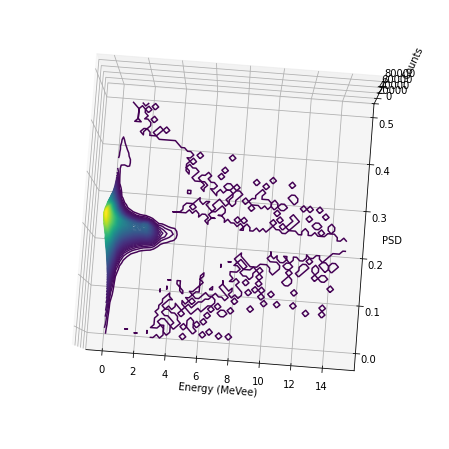

In [20]:
start_frame=(90,-90)  # top view
transitions = [ # end view
    (-90, 0),   # 0, -90   (energy vs counts)
    (0, 90),    # 0, 0     (psd vs counts)
    (45, -45),  # 45, -45  (corner view)
    (0, 360),   # 45, -45  (full circle)
    (45, -45)   # 90, -90  (back to start)
]
hold_frames=[30, 30, 30, 0, 0]
transition_frames=[10,10,10,120,10]

island_plot(lim_psd, transitions, hold_frames, transition_frames, start_frame=start_frame, 
            histogram_res=resolution, contour_res = 100, save=True, save_file='all_experiments_island.gif')

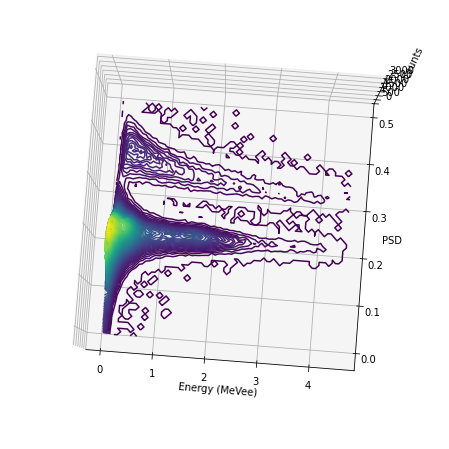

In [21]:
island_plot(ambe_report, transitions, hold_frames, transition_frames, start_frame=(90,-90),
           histogram_res=resolution, contour_res = 100, save=True, save_file='ambe_island.gif')

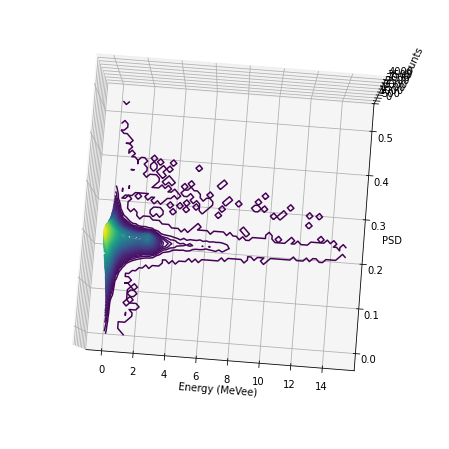

In [22]:
island_plot(experiments['20220801']['echem_plasma'], 
            transitions, hold_frames, transition_frames, start_frame=(90,-90),
            histogram_res=resolution, contour_res = 100, save=True, save_file='summer_ep_island.gif')

In [23]:
# defining settings for ?
psd_bin_lbs = ye[:-1]
# TODO programmatically get max count
fit_bounds = (
    (0.21, 0.001, 1, 
     0.32, 0.001, 1),
    (0.25, 0.08, 20e4,
     0.38, 0.08, 2e4)
)

In [24]:
def split_params(params):
    params = abs(params)
    return params[0:3], params[3:]

def log_bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return np.log(bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2))

def scan_histogram_slices(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    end_idx = min(len(histogram), end_idx)
    slice_params = []
    slice_err = []
    for i in range(start_idx, end_idx):
        params, cov = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )
        perr = np.sqrt(np.diag(cov))
        gamma_params, neutron_params = split_params(params)
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        slice_params.append((i, *params, fom))
        slice_err.append((i, *perr))

    df = pd.DataFrame(slice_params, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2', 'fom'])
    err_df = pd.DataFrame(slice_err, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2'])
    return df, err_df

def find_threshold_fom_slice(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    # TODO redefine in terms of scan_histogram_slices()
    end_idx = min(len(histogram), end_idx)
    for i in range(start_idx, end_idx):
        params, _ = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )

        gamma_params, neutron_params = split_params(params)

        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])

        if round(fom, 3) >= 1.269:
            return i, params

In [25]:
# getting threshold FOM slice index
fom_idx, params = find_threshold_fom_slice(psd_bin_lbs, Z.T, fit_bounds, 2, 200)
fom_idx

2

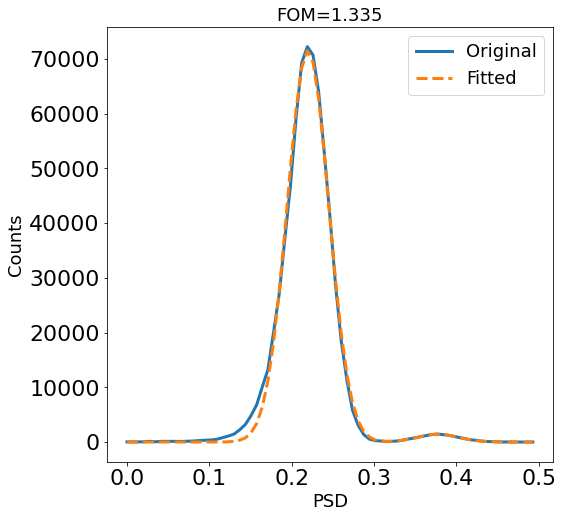

In [26]:
# looking at threshold FOM slice
histogram_slice = Z.T[:,fom_idx]

# params, _ = curve_fit(
#     bimodal,
#     psd_bin_lbs, 
#     histogram_slice,
#     bounds=fit_bounds
# )
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, histogram_slice, lw=3, label="Original")
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), '--', lw=3, label="Fitted")

gamma_params, neutron_params = split_params(params)

ax.set_title(f"FOM={FOM(*gamma_params[:-1], *neutron_params[:-1]):.3f}", fontsize=fontsize)
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [27]:
# TODO programmatically check multiple resolutions and get ideal FOM slice
# (also graphs)

In [28]:
# scan PSD/energy histogram
df, err_df = scan_histogram_slices(psd_bin_lbs, Z.T, fit_bounds, 0, 200)

In [29]:
# super-awesome histogram scan animation
%matplotlib notebook
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(8,8))
ax = plt.axes(xlim=(0, 0.5), ylim=(0,50e3))

line1, = ax.plot([], [], 'k', lw=3, label='Actual')
line2, = ax.plot([], [], 'r--', lw=3, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD')
    ax.set_ylabel('N')
    return line1, line2
def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
#     mu1, _, a1, mu2, _, a2 = params
#     ax.vlines([mu1, mu2], [0, 0], [a1, a2])
    ax.set_title(f"i={i}, E={xe[i]:.3f} MeVee, FOM={fom:.3f}")

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=len(psd_bin_lbs), interval=160, blit=True)
anim.save('psd_big.gif', writer='pillow')

<IPython.core.display.Javascript object>

In [30]:
%matplotlib inline

In [31]:
def fit_to_poly(x, y, degree):
    return np.poly1d(np.polyfit(x, y, degree))

def get_param_slice(dataframe, col_label, min, max):
    return dataframe[col_label][min:max]

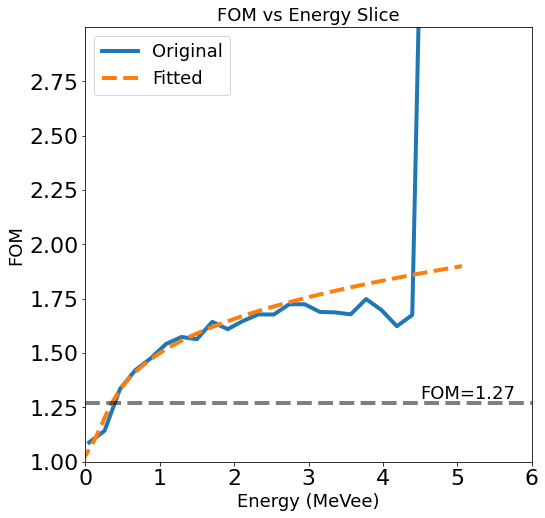

In [32]:
# index vs FOM
fom_fit = fit_to_poly(df['fom'][0:10], xe[0:10], 3)
fom_space = np.linspace(1, 1.9, 100)

fig, ax = plt.subplots(figsize=(8,8))

ax.plot(xe[:-1], df['fom'], label="Original", lw=4)
ax.plot(fom_fit(fom_space), fom_space, '--', label="Fitted", lw=4)
ax.hlines(1.27, 0, resolution, color='k', linestyle='--', alpha=0.5, lw=4)
ax.text(*(4.5, 1.27 + 0.02), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(1,3)
ax.set_xlim(0,6)

ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

ax.legend(fontsize=fontsize)

ax.set_yticks(np.arange(1,3,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [33]:
L0 = fom_fit(1.27)
cutoffs.append(L0)
L0

0.3554122347760682

In [34]:
L3

4.139403167211167

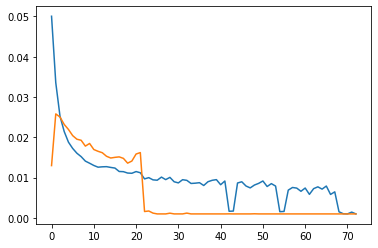

In [35]:
# index vs sigma
plt.plot(range(0, resolution), df['sigma1'], df['sigma2'])

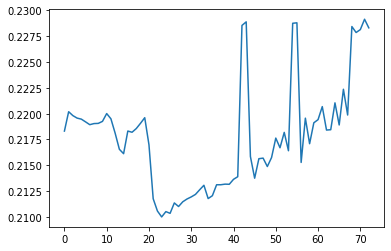

In [36]:
plt.plot(range(0, resolution), df['mu1'])

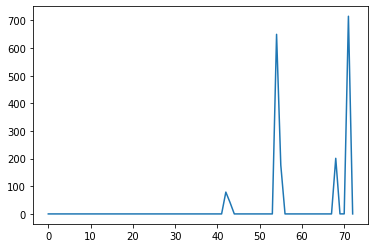

In [37]:
# index vs. sigma error
plt.plot(range(0, resolution), err_df['mu1'])

In [38]:
# settings for window fitting
poly_degree = 4  # TODO need this?
n_window_height = 4
g_window_height = 8
max_slice_idx = 65  # TODO determine programmatically

n_window_offset = n_window_height/2
g_window_offset = g_window_height/2
min_slice_idx = fom_idx - 1

all_slice_xs = xe[:-1]
fitting_slice_xs = xe[min_slice_idx:max_slice_idx]

In [39]:
def interp(x, y):
    return interp1d(x, y, "previous", fill_value="extrapolate")

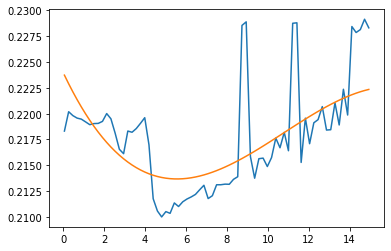

In [40]:
# mu1 fitting
mu1_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'mu1', min_slice_idx, max_slice_idx), 3)
# mu1_fit = interp(fitting_slice_xs, get_param_slice(df, 'mu1', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['mu1'])
plt.plot(all_slice_xs, mu1_fit(all_slice_xs))

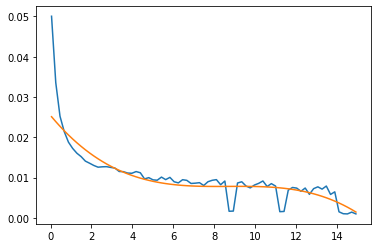

In [41]:
# sigma1 fitting
sigma1_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'sigma1', min_slice_idx, max_slice_idx), 3)
# sigma1_fit = interp(fitting_slice_xs, get_param_slice(df, 'sigma1', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['sigma1'])
plt.plot(all_slice_xs, sigma1_fit(all_slice_xs))
# QUESTION do we need to be tighter to real vals at low E?
# we didn't with mu1...

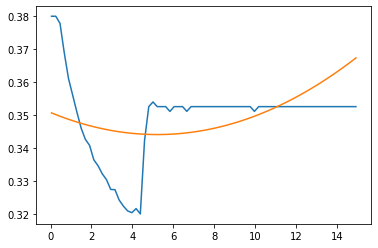

In [42]:
# mu2 fitting
mu2_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'mu2', min_slice_idx, max_slice_idx), 2)
# mu2_fit = interp(fitting_slice_xs, get_param_slice(df, 'mu2', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['mu2'])
plt.plot(all_slice_xs, mu2_fit(all_slice_xs))

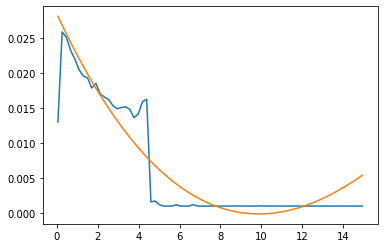

In [43]:
# sigma2 fitting
sigma2_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'sigma2', min_slice_idx, max_slice_idx), 3)
# sigma2_fit = interp(fitting_slice_xs, get_param_slice(df, 'sigma2', min_slice_idx, max_slice_idx))
plt.plot(all_slice_xs, df['sigma2'])
plt.plot(all_slice_xs, sigma2_fit(all_slice_xs))
# low E fit problems again...

In [44]:
# window fitting
# lb_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs), 3))
# lb_fit = interp1d(fitting_slice_xs, mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs), "quadratic", fill_value="extrapolate")

# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, 0.2 + (mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs)), 3))
# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu2_fit(fitting_slice_xs)+g_window_offset*sigma2_fit(fitting_slice_xs), 3))
# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu2_fit(fitting_slice_xs)+8*sigma1_fit(fitting_slice_xs), 4))

def exponential(x, a, b, c, d):
    return a*np.exp(b*x) + c*np.exp(d*x)

lb_fit_params, _ = curve_fit(
    exponential,
    fitting_slice_xs,
    mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs),
)

def lb_fit(energy):
    return exponential(energy, *lb_fit_params)

def ub_fit(energy):
    return lb_fit(energy) + 0.2

def classify(psd_report, energy_cutoff_limit=8):
    neutron_filter = psd_report["tail / total"].between(lb_fit(psd_report["energy"].astype(float)), ub_fit(psd_report["energy"].astype(float))) & psd_report["energy"].between(0,energy_cutoff_limit)
    neutrons = psd_report[neutron_filter]
    gammas = psd_report[~neutron_filter]
    
    return neutrons, gammas

def plot_classification(neutrons, gammas, energy_cutoff_limit=8):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["energy"], gammas["tail / total"], s=2, label="Gammas")
    ax.scatter(neutrons["energy"], neutrons["tail / total"], s=2, label="Neutrons")

    energy_space = np.linspace(xe[0], energy_cutoff_limit, 100)
    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')
    ax.vlines(energy_cutoff_limit, lb_fit(energy_cutoff_limit), ub_fit(energy_cutoff_limit), 'r', ls='--')

    for ep in cutoffs:
        ax.vlines(ep, lb_fit(ep), ub_fit(ep), 'k', alpha=0.5)

    # ax.text(*(L0+.05, 0.4), "FOM=1.27", rotation="vertical")
    # ax.text(*(L1+.05, 0.4), "2.5 MeVee", rotation="vertical")
    # ax.text(*(L2+.05, 0.4), "4.0 MeVee", rotation="vertical")
    # ax.text(*(L3+.05, 0.39), "8.5 MeVee", rotation="vertical")
    ax.set_title("Counting Window Compiled from Experiments", fontsize=fontsize)
    ax.text(*(6.4, 0.5), f"N={neutrons.shape[0]}", fontsize=fontsize)
    ax.set_ylim(0,0.6)
    ax.set_xlim(0,energy_cutoff_limit)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

C:\Users\Alvin\AppData\Local\Temp\ipykernel_9596\1856746701.py:10: RuntimeWarning: overflow encountered in exp
  return a*np.exp(b*x) + c*np.exp(d*x)


In [45]:
energy_space = np.linspace(xe[0], 8, 100)

In [ ]:
neutrons, gammas = classify(psd_report)
fig, ax = plot_classification(neutrons, gammas)

In [ ]:
counts_n, bins_n = np.histogram(neutrons["energy"], bins=resolution)

In [ ]:
bins_n[1] - bins_n[0]

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
# ax.stairs(counts_n, bins_n)
ax.plot(bins_n[:-1], counts_n)
ax.set_xlim(0, 8)
ax.set_ylim(0)

In [ ]:
summer_psd_report = experiments["20220801"]
summer_classification = {exp_key: classify(experiment_data) for exp_key, experiment_data in summer_psd_report.items()}
summer_histograms = {exp_type: np.histogram(exp_data[0]["energy"], bins=resolution * 2) for exp_type, exp_data in summer_classification.items()}

In [ ]:
summer_echem_plasma_counts = summer_histograms["echem_plasma"][0]
summer_background_counts = summer_histograms["background"][0]
summer_bins = summer_histograms["echem_plasma"][1]

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(summer_bins[:-1], summer_echem_plasma_counts - summer_background_counts)
    
ax.set_xlim(0, 8)
ax.set_ylim(0)

ax.vlines(cutoffs, 0, 1e3, 'k', 'dashed', alpha=0.2)

In [ ]:
non_background = {k: v for k, v in summer_histograms.items() if k != "background"}

In [ ]:
def energy_resolution(lo):
    a=0.102
    b=0.102
    c=0.036
    return np.sqrt(a**2 + b**2/lo + (c/lo)**2)


plt.plot(energy_space, energy_resolution(energy_space))

In [ ]:
lo_res = energy_resolution(np.array(cutoffs))

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

for label, histogram in non_background.items():
    counts, bins = histogram
    ax.plot(bins[:-1], counts - summer_background_counts, label=label)
    
ax.set_xlim(L0, 8)

ylims = (-30, 60)
ax.set_ylim(ylims)

ax.vlines(cutoffs, -1e3, 1e3, 'k', 'dashed', alpha=0.2)
ax.hlines(0, 0, 8, 'k', label="background", alpha=0.3)

ax.text(*(L1+.05, 38), "2.5 MeVee", rotation="vertical", fontsize=14, alpha=0.7)
ax.text(*(L2+.05, 38), "4.0 MeVee", rotation="vertical", fontsize=14, alpha=0.7)
ax.text(*(L3+.05, 38), "8.5 MeVee", rotation="vertical", fontsize=14, alpha=0.7)


y_space = [*ylims]
ax.fill_betweenx(y_space, [L1 - lo_res[0]] * 2, [L1 + lo_res[0]] * 2, alpha=0.1, color="orange")
ax.fill_betweenx(y_space, [L2 - lo_res[1]] * 2, [L2 + lo_res[1]] * 2, alpha=0.1, color="orange")
ax.fill_betweenx(y_space, [L3 - lo_res[2]] * 2, [L3 + lo_res[2]] * 2, alpha=0.1, color="orange")

ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)

ax.set_title("Counts over Background Energy", fontsize=16)
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

In [ ]:
def get_counts_between(psd_report, le, ue):
    return psd_report[psd_report["energy"].between(le, ue)].shape[0]

indexes = summer_psd_report.keys()
columns = ["total", "2.5", "4.0", "8.5"]
summer_counts = pd.DataFrame([], columns=columns, index=indexes)

for exp_type, exp_data in summer_classification.items():
    count_2_5 = get_counts_between(exp_data[0], L0, L1)
    count_4_0 = get_counts_between(exp_data[0], L1, L2)
    count_8_5 = get_counts_between(exp_data[0], L2, L3)
    count_total = exp_data[0].shape[0]
    
    counts = count_total, count_2_5, count_4_0, count_8_5
    
    summer_counts.loc[exp_type] = counts
    
summer_counts

In [ ]:
err_indexes = ["echem", "echem_plasma", "plasma"]
summer_errors = pd.DataFrame([], columns=columns, index=err_indexes)

for exp_type in err_indexes:
    summer_errors.loc[exp_type] = np.sqrt(np.array(summer_counts.loc[exp_type] + summer_counts.loc["background"], dtype=float))
    
summer_errors

In [ ]:
# (val_count - bg_count) / stdev -> int, rounded down
summer_sigs = pd.DataFrame([], columns=columns, index=err_indexes)

for exp_type in err_indexes:
    summer_sigs.loc[exp_type] = np.floor(
        np.array(
            (summer_counts.loc[exp_type] - summer_counts.loc["background"]) / summer_errors.loc[exp_type], 
            dtype=float
        )
    )

summer_sigs.astype(int)

In [ ]:
# count / stdev

summer_counts_over_bg = pd.DataFrame([], columns=columns, index=err_indexes)
summer_counts_report = pd.DataFrame([], columns=columns, index=err_indexes)


t_e = 2371.31
t_ep = 2352.48
t_p = 2000.05
t_bg = 11200.69

times = {
    "background": t_bg,
    "echem": t_e,
    "echem_plasma": t_ep,
    "plasma": t_p
}

for exp_type in err_indexes:
    this_count =  summer_counts.loc[exp_type]
    bg_count = summer_counts.loc["background"]
    
    summer_counts_over_bg.loc[exp_type] = rel_count = this_count/times[exp_type] - bg_count/times["background"]
    
    summer_counts_report.loc[exp_type] = [f"{count:.4f} / {sig:.0f}σ" for count, sig in zip(rel_count, summer_sigs.loc[exp_type])]

summer_counts_report

In [ ]:
summer_counts_over_bg["total"]

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar("July 31", summer_counts_over_bg["total"]["echem"], fmt = "o", markersize=12, linestyle="", label="Echem", capsize=12)
ax.errorbar("July 31", summer_counts_over_bg["total"]["plasma"], fmt = "o", markersize=12, linestyle="", label="Plasma", capsize=12)
ax.errorbar("July 31", summer_counts_over_bg["total"]["echem_plasma"], fmt = "o", markersize=12, linestyle="", label="Echem+Plasma", capsize=12)
ax.errorbar("July 31", 0.01, fmt = "o", markersize=12, linestyle="", label="Control", capsize=12)
ax.set_ylabel("Rate $(s^{{-1}})$", fontsize=26)

# ax.set_yticks(np.arange(0,0.4,0.1))
ax.set_ylim(-0.1, 0.5)
fig.suptitle("Count Rate Over Background", fontsize=26)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
ax.grid()
ax.legend(fontsize=18)
fig.tight_layout()
plt.show()

In [ ]:
ambe_neutrons, ambe_gammas = classify(ambe_report)
ambe_histogram = np.histogram(ambe_neutrons["energy"], bins=resolution * 2)

fig, ax = plt.subplots(figsize=(12,6))
counts, bins = ambe_histogram
ax.plot(bins[:-1], counts)
    
ax.set_xlim(0, 8)
ax.set_ylim(0)

ax.vlines([L1, L2], 0, 3e3, 'k', 'dashed', alpha=0.2)